In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


# Read

In [3]:
root = "D:/Admin/source_data/"

In [4]:
price = pd.read_csv(root + "2017PurchasePricesDec.csv")
begInv = pd.read_csv(root + "BegInvFINAL12312016.csv")
endInv = pd.read_csv(root + "EndInvFINAL12312016.csv")
invoice = pd.read_csv(root + "InvoicePurchases12312016.csv")
purchase = pd.read_csv(root + "PurchasesFINAL12312016.csv")
sales = pd.read_csv(root + "SalesFINAL12312016.csv")

all_table = {
    "price": price,
    "begin": begInv,
    "end": endInv,
    "invoice": invoice,
    "purchase": purchase,
    "sales": sales
}

name_table = ["price", "begin", "end", "invoice", "purchase", "sales"]

# Dữ liệu lỗi, tiền xử lý

In [5]:
for name in name_table:
    table = all_table[name]
    print(f"\nTable {name} include {table.shape[1]} columns:")
    print(table.columns.tolist())


Table price include 9 columns:
['Brand', 'Description', 'Price', 'Size', 'Volume', 'Classification', 'PurchasePrice', 'VendorNumber', 'VendorName']

Table begin include 9 columns:
['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'startDate']

Table end include 9 columns:
['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'endDate']

Table invoice include 10 columns:
['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate', 'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval']

Table purchase include 16 columns:
['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'VendorNumber', 'VendorName', 'PONumber', 'PODate', 'ReceivingDate', 'InvoiceDate', 'PayDate', 'PurchasePrice', 'Quantity', 'Dollars', 'Classification']

Table sales include 14 columns:
['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'SalesQuantity', 'SalesDollars', 'SalesPrice', 'SalesDate', 'Volume', 'Classification', 'ExciseTax', 

In [31]:
invoice

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2016-01-04,8124,2015-12-21,2016-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2016-01-07,8137,2015-12-22,2016-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2016-01-09,8169,2015-12-24,2016-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2016-01-12,8106,2015-12-20,2016-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2016-01-07,8170,2015-12-24,2016-02-12,1935,15527.25,429.20,None
...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2017-01-06,13626,2016-12-21,2017-02-10,90,1563.00,8.60,None
5539,9625,WESTERN SPIRITS BEVERAGE CO,2017-01-10,13661,2016-12-23,2017-02-18,4617,37300.48,186.50,None
5540,3664,WILLIAM GRANT & SONS INC,2017-01-02,13643,2016-12-22,2017-02-04,9848,202815.78,932.95,None
5541,9815,WINE GROUP INC,2017-01-03,13602,2016-12-20,2017-02-08,24747,149007.56,819.54,None


In [24]:
purchase['PODate']

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2015-12-21,2016-01-02,2016-01-04,2016-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-01,2016-01-07,2016-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-02,2016-01-07,2016-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-01,2016-01-07,2016-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2015-12-24,2016-01-02,2016-01-09,2016-02-16,21.32,5,106.60,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2372469,49_GARIGILL_22298,49,22298,Zorvino Vyds Sangiovese,750mL,90058,ZORVINO VINEYARDS,13593,2016-12-19,2016-12-28,2017-01-09,2017-02-06,8.06,12,96.72,2
2372470,1_HARDERSFIELD_19556,1,19556,Zorvino Bacca Z Blackberry,750mL,90058,ZORVINO VINEYARDS,13593,2016-12-19,2016-12-27,2017-01-09,2017-02-06,9.39,12,112.68,2
2372471,66_EANVERNESS_22297,66,22297,Zorvino Vyds Pearz,750mL,90058,ZORVINO VINEYARDS,13593,2016-12-19,2016-12-26,2017-01-09,2017-02-06,6.75,12,81.00,2
2372472,69_MOUNTMEND_19557,69,19557,Zorvino Fragole Z Strawberry,750mL,90058,ZORVINO VINEYARDS,13593,2016-12-19,2016-12-26,2017-01-09,2017-02-06,9.39,12,112.68,2


In [32]:
price

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.
...,...,...,...,...,...,...,...,...,...
12256,44917,Ferreira 10-Yr Tawny Port,24.99,750mL,750,2,16.55,90024,VINILANDIA USA
12257,44944,Sanford Santa Rita Pnt Nr,22.99,750mL,750,2,14.93,4425,MARTIGNETTI COMPANIES
12258,45016,Neal One Lane Bridg Cab Svgn,93.99,750mL,750,2,61.43,10754,PERFECTA WINES
12259,46011,Folonari Pnt Nr Venezie,12.99,1500ml,1500,2,8.90,9744,FREDERICK WILDMAN & SONS


In [42]:
sales.groupby(['Store', 'SalesDate', 'Description', 'Size']).sum()

Brand  \
Store SalesDate  Description                  Size  Classification          
1     2016-01-01 1800 Reposado Gold Tequila   50mL  1                8470   
                 Absolut Mandrin              50mL  1                8027   
                 Absolut Raspberri            750mL 1                3584   
                 Absolut Vanilia              50mL  1                3571   
                 After Shock Hot & Cool Cinmn 50mL  1                5457   
...                                                                   ...   
81    2016-12-31 Z Alexander Brown Uncaged Ca 750mL 2               25524   
                 Zhenka Pink Lemonade Vodka   1.75L 1                3041   
                 Zhenka Vodka 100 Proof       1.75L 1                3894   
                 Zorvino Bacca Z Blackberry   750mL 2               19556   
                 Zorvino Vyds Mango Magnifico 750mL 2               25125   

                                                                    SalesQuantity  \
Store SalesDate  Description                  Size  Classification                  
1     2016-01-01 1800 Reposado Gold Tequila   50mL  1                           2   
                 Absolut Mandrin              50mL  1                           3   
                 Absolut Raspberri            750mL 1                           1   
                 Absolut Vanilia              50mL  1                           2   
                 After Shock Hot & Cool Cinmn 50mL  1                           1   
...                                                                           ...   
81    2016-12-31 Z Alexander Brown Uncaged Ca 750mL 2                           1   
                 Zhenka Pink Lemonade Vodka   1.75L 1                           2   
                 Zhenka Vodka 100 Proof       1.75L 1                           1   
                 Zorvino Bacca Z Blackberry   750mL 2                           1   
                 Zorvino Vyds Mango Magnifico 750mL 2                           2   

                                                                    SalesDollars  \
Store SalesDate  Description                  Size  Classification                 
1     2016-01-01 1800 Reposado Gold Tequila   50mL  1                       5.58   
                 Absolut Mandrin              50mL  1                       5.97   
                 Absolut Raspberri            750mL 1                      17.99   
                 Absolut Vanilia              50mL  1                       3.98   
                 After Shock Hot & Cool Cinmn 50mL  1                       1.99   
...                                                                          ...   
81    2016-12-31 Z Alexander Brown Uncaged Ca 750mL 2                      14.99   
                 Zhenka Pink Lemonade Vodka   1.75L 1                      17.98   
                 Zhenka Vodka 100 Proof       1.75L 1                      11.99   
                 Zorvino Bacca Z Blackberry   750mL 2                      13.99   
                 Zorvino Vyds Mango Magnifico 750mL 2                      24.98   

                                                                    SalesPrice  \
Store SalesDate  Description                  Size  Classification               
1     2016-01-01 1800 Reposado Gold Tequila   50mL  1                     2.79   
                 Absolut Mandrin              50mL  1                     1.99   
                 Absolut Raspberri            750mL 1                    17.99   
                 Absolut Vanilia              50mL  1                     1.99   
                 After Shock Hot & Cool Cinmn 50mL  1                     1.99   
...                                                                        ...   
81    2016-12-31 Z Alexander Brown Uncaged Ca 750mL 2                    14.99   
                 Zhenka Pink Lemonade Vodka   1.75L 1                     8.99   
                 Zhenka Vodka 100 Proof       1

In [43]:
12825363 - 12823808 

1555

In [40]:
sales

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2016-01-01,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2016-01-02,750.0,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2016-01-03,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2016-01-08,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2016-01-09,375.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12825358,9_BLACKPOOL_984,9,984,Patron XO Cafe Liqueur,750mL,1,25.99,25.99,2016-12-17,750.0,1,0.79,9165,ULTRA BEVERAGE COMPANY LLP
12825359,9_BLACKPOOL_984,9,984,Patron XO Cafe Liqueur,750mL,1,25.99,25.99,2016-12-21,750.0,1,0.79,9165,ULTRA BEVERAGE COMPANY LLP
12825360,9_BLACKPOOL_984,9,984,Patron XO Cafe Liqueur,750mL,3,77.97,25.99,2016-12-23,750.0,1,2.36,9165,ULTRA BEVERAGE COMPANY LLP
12825361,9_BLACKPOOL_984,9,984,Patron XO Cafe Liqueur,750mL,1,25.99,25.99,2016-12-24,750.0,1,0.79,9165,ULTRA BEVERAGE COMPANY LLP


In [16]:
begInv['Store'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79], dtype=int64)

In [5]:
# --- A. Chuyển đổi định dạng Ngày tháng (Date Conversion) ---
# Các bảng có cột ngày tháng cần được chuyển về datetime
date_columns = {
    'begin': ['startDate'],
    'end': ['endDate'],
    'invoice': ['InvoiceDate', 'PODate', 'PayDate'],
    'purchase': ['PODate', 'ReceivingDate', 'InvoiceDate', 'PayDate'],
    'sales': ['SalesDate']
}

for table_name, cols in date_columns.items():
    for col in cols:
        all_table[table_name][col] = pd.to_datetime(all_table[table_name][col], errors='coerce')

In [6]:
# --- B. Xử lý giá trị thiếu (Missing Values) ---
def check_missing_values(data_dict):
    for name, df in data_dict.items():
        print(f"--- Missing values in {name} ---")
        print(df.isnull().sum()[df.isnull().sum() > 0])
        print("\n")

check_missing_values(all_table)

--- Missing values in price ---
Description    1
Size           1
Volume         1
dtype: int64


--- Missing values in begin ---
Series([], dtype: int64)


--- Missing values in end ---
City    1284
dtype: int64


--- Missing values in invoice ---
Series([], dtype: int64)


--- Missing values in purchase ---
Size    3
dtype: int64


--- Missing values in sales ---
Series([], dtype: int64)




In [8]:
print("--- Xử lý dữ liệu trùng lặp ---")
for name, df in all_table.items():
    print(f"Table {name:<10}: Đã xóa {df.duplicated().sum()} dòng trùng.")
    df.drop_duplicates(inplace=True)

--- Xử lý dữ liệu trùng lặp ---
Table price     : Đã xóa 0 dòng trùng.
Table begin     : Đã xóa 0 dòng trùng.
Table end       : Đã xóa 0 dòng trùng.
Table invoice   : Đã xóa 0 dòng trùng.
Table purchase  : Đã xóa 0 dòng trùng.
Table sales     : Đã xóa 0 dòng trùng.


In [9]:
# Định nghĩa các cột ngày tháng chính cho từng bảng để kiểm tra
target_date_cols = {
    "begin": "startDate",
    "end": "endDate",
    "invoice": "InvoiceDate",   # Ngày hóa đơn (Giao dịch tài chính)
    "purchase": "ReceivingDate", # Ngày nhận hàng thực tế (Giao dịch kho)
    "sales": "SalesDate"
}

print(f"{'Table':<10} | {'Column':<15} | {'Start Date':<12} | {'End Date':<12} | {'Duration (Days)'}")
print("-" * 75)

for name in name_table:
    df = all_table[name]
    
    # Bảng Price thường là bảng tham chiếu, không có cột ngày tháng giao dịch
    if name == "price":
        print(f"{name:<10} | {'N/A':<15} | {'Dữ liệu tham chiếu (Master Data)':<30}")
        continue

    # Lấy tên cột ngày tháng tương ứng
    col = target_date_cols.get(name)
    
    if col in df.columns:
        # Đảm bảo dữ liệu là datetime
        df[col] = pd.to_datetime(df[col], errors='coerce')
        
        min_date = df[col].min()
        max_date = df[col].max()
        
        if pd.notnull(min_date) and pd.notnull(max_date):
            duration = (max_date - min_date).days
            print(f"{name:<10} | {col:<15} | {min_date.strftime('%Y-%m-%d')} | {max_date.strftime('%Y-%m-%d')} | {duration}")
        else:
             print(f"{name:<10} | {col:<15} | {'Empty/Null'}")
    else:
        print(f"{name:<10} | {col:<15} | Not Found")

Table      | Column          | Start Date   | End Date     | Duration (Days)
---------------------------------------------------------------------------
price      | N/A             | Dữ liệu tham chiếu (Master Data)
begin      | startDate       | 2016-01-01 | 2016-01-01 | 0
end        | endDate         | 2016-12-31 | 2016-12-31 | 0
invoice    | InvoiceDate     | 2016-01-04 | 2017-01-10 | 372
purchase   | ReceivingDate   | 2016-01-01 | 2016-12-31 | 365
sales      | SalesDate       | 2016-01-01 | 2016-12-31 | 365


# Phân phối dữ liệu

## Histogram

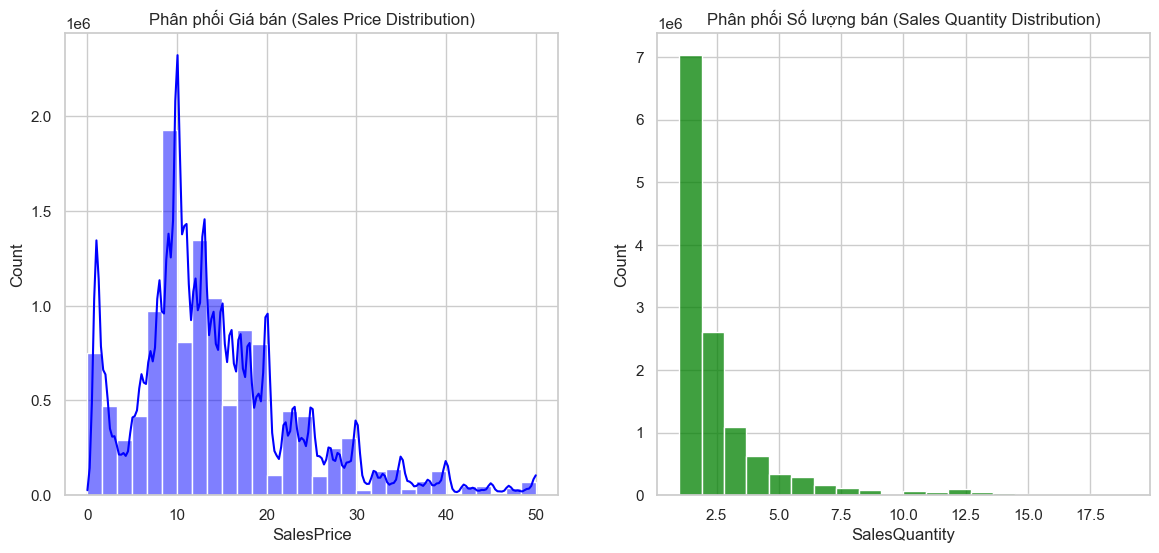

In [10]:
plt.figure(figsize=(14, 6))

# Phân phối Giá bán (SalesPrice)
plt.subplot(1, 2, 1)
sns.histplot(sales[sales['SalesPrice'] < 50]['SalesPrice'], bins=30, kde=True, color='blue') 
# Note: Lọc < 50 để nhìn rõ hơn nếu có outliers quá lớn
plt.title('Phân phối Giá bán (Sales Price Distribution)')

# Phân phối Số lượng bán (SalesQuantity)
plt.subplot(1, 2, 2)
sns.histplot(sales[sales['SalesQuantity'] < 20]['SalesQuantity'], bins=20, kde=False, color='green')
plt.title('Phân phối Số lượng bán (Sales Quantity Distribution)')

plt.show()

## Pareto

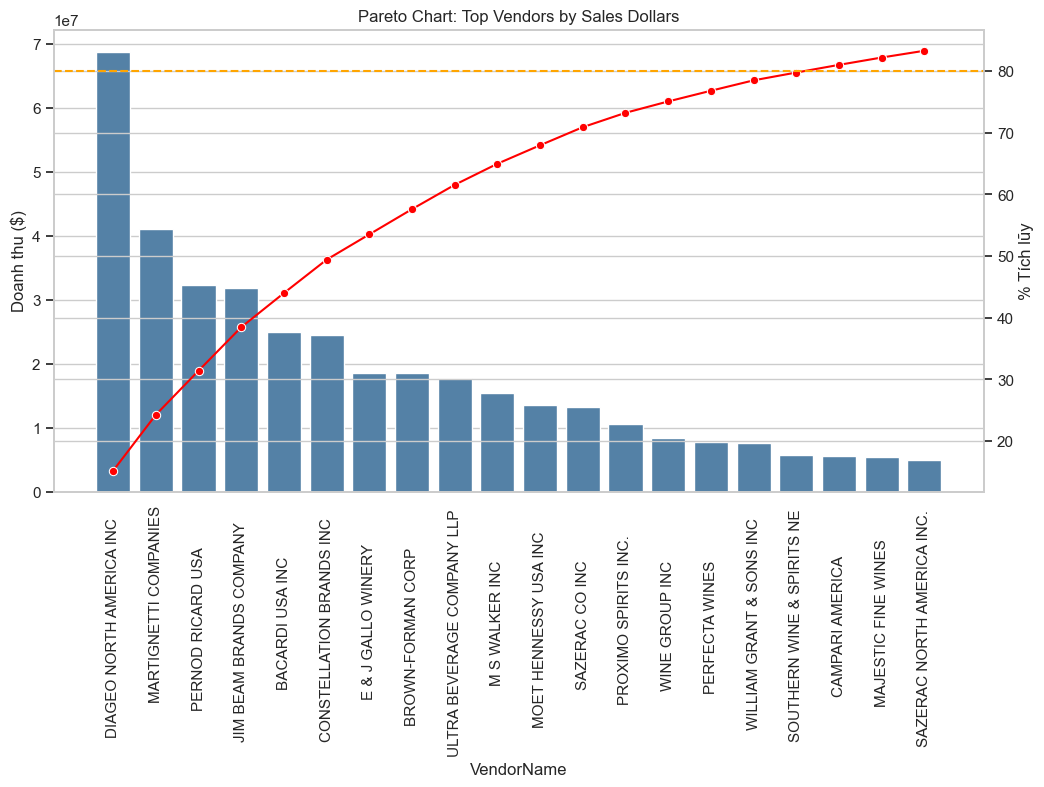

In [11]:
# Tính tổng doanh thu theo Vendor
top_vendors = sales.groupby('VendorName')['SalesDollars'].sum().sort_values(ascending=False).reset_index()

# Tính % tích lũy
top_vendors['cumulative_sum'] = top_vendors['SalesDollars'].cumsum()
top_vendors['cumulative_perc'] = 100 * top_vendors['cumulative_sum'] / top_vendors['SalesDollars'].sum()

# Lấy Top 20 Vendor để vẽ cho gọn
top_20_vendors = top_vendors.head(20)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart: Doanh thu
sns.barplot(data=top_20_vendors, x='VendorName', y='SalesDollars', color='steelblue', ax=ax1)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
ax1.set_ylabel('Doanh thu ($)')

# Line chart: % Tích lũy
ax2 = ax1.twinx()
sns.lineplot(data=top_20_vendors, x='VendorName', y='cumulative_perc', color='red', marker='o', ax=ax2)
ax2.set_ylabel('% Tích lũy')
ax2.axhline(80, color='orange', linestyle='--') # Đường 80%

plt.title('Pareto Chart: Top Vendors by Sales Dollars')
plt.show()

`Phân tích: Nếu đường màu đỏ chạm mốc 80% chỉ với một số ít Vendor (bên trái), điều này chứng tỏ cửa hàng phụ thuộc lớn vào các nhà cung cấp này.`


## Distribution

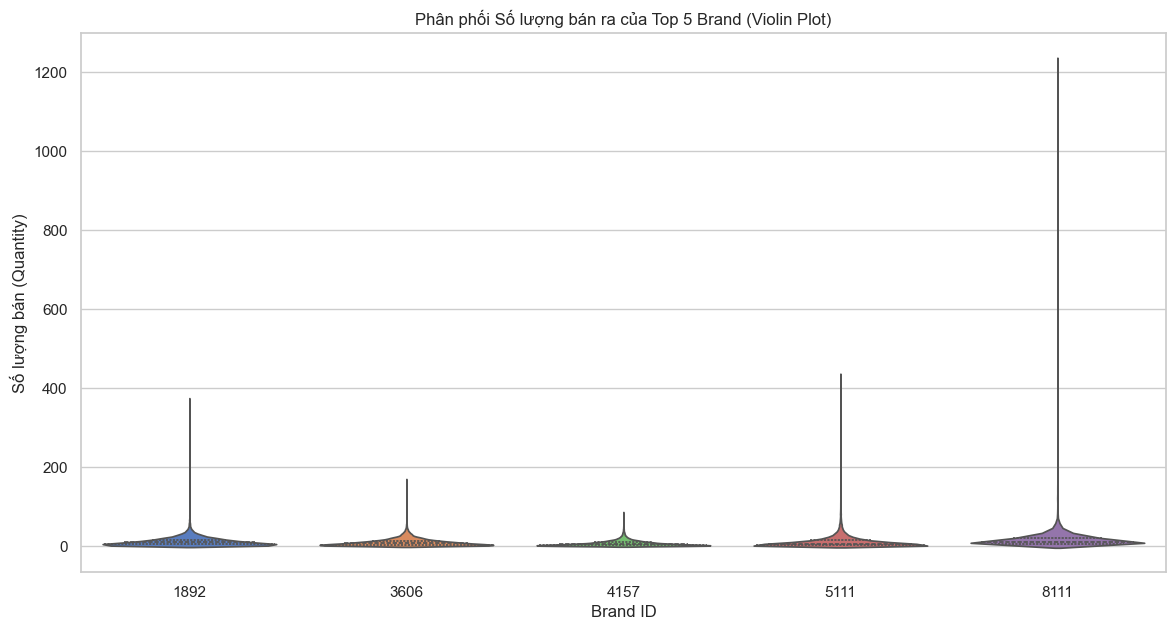

In [12]:
# Lọc Top 5 Brand bán chạy nhất
top_brands = sales['Brand'].value_counts().head(5).index
df_top_brands = sales[sales['Brand'].isin(top_brands)]

plt.figure(figsize=(14, 7))

# Vẽ Violin plot cho Số lượng bán ra của Top 5 Brand
sns.violinplot(x='Brand', y='SalesQuantity', data=df_top_brands, palette="muted", inner="quartile")

plt.title('Phân phối Số lượng bán ra của Top 5 Brand (Violin Plot)')
plt.xlabel('Brand ID')
plt.ylabel('Số lượng bán (Quantity)')
plt.show()

# Scatter

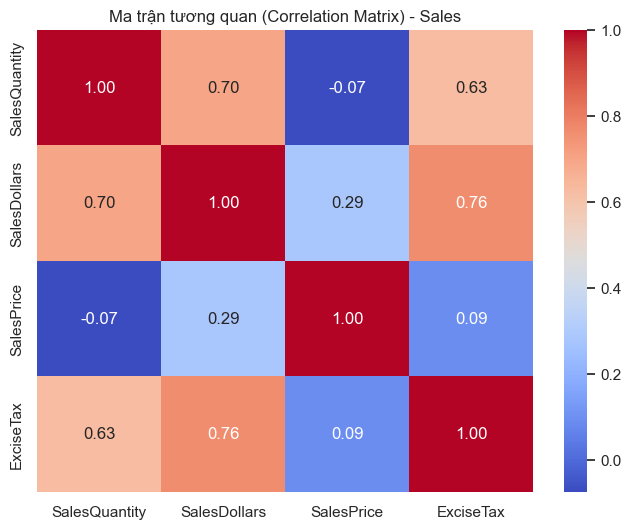

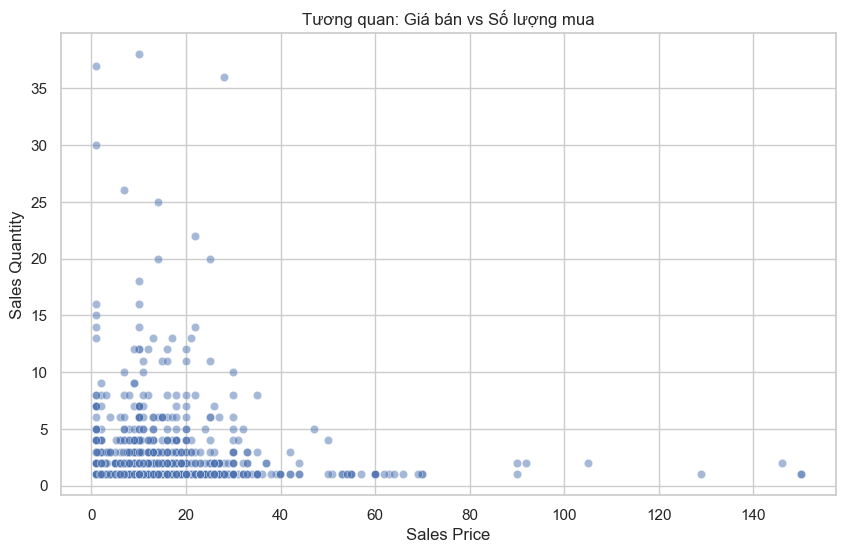

In [13]:
# --- Correlation Matrix (Heatmap) ---
# Chọn các cột số quan trọng trong bảng Sales
cols_corr = ['SalesQuantity', 'SalesDollars', 'SalesPrice', 'ExciseTax']
corr_matrix = sales[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan (Correlation Matrix) - Sales')
plt.show()

# --- Scatter Plot ---

plt.figure(figsize=(10, 6))
# Lấy mẫu random 1000 điểm để vẽ cho nhanh
sns.scatterplot(data=sales, x='SalesPrice', y='SalesQuantity', alpha=0.5)
plt.xlabel('Sales Price')
plt.ylabel('Sales Quantity')
plt.show()

# Seasonal

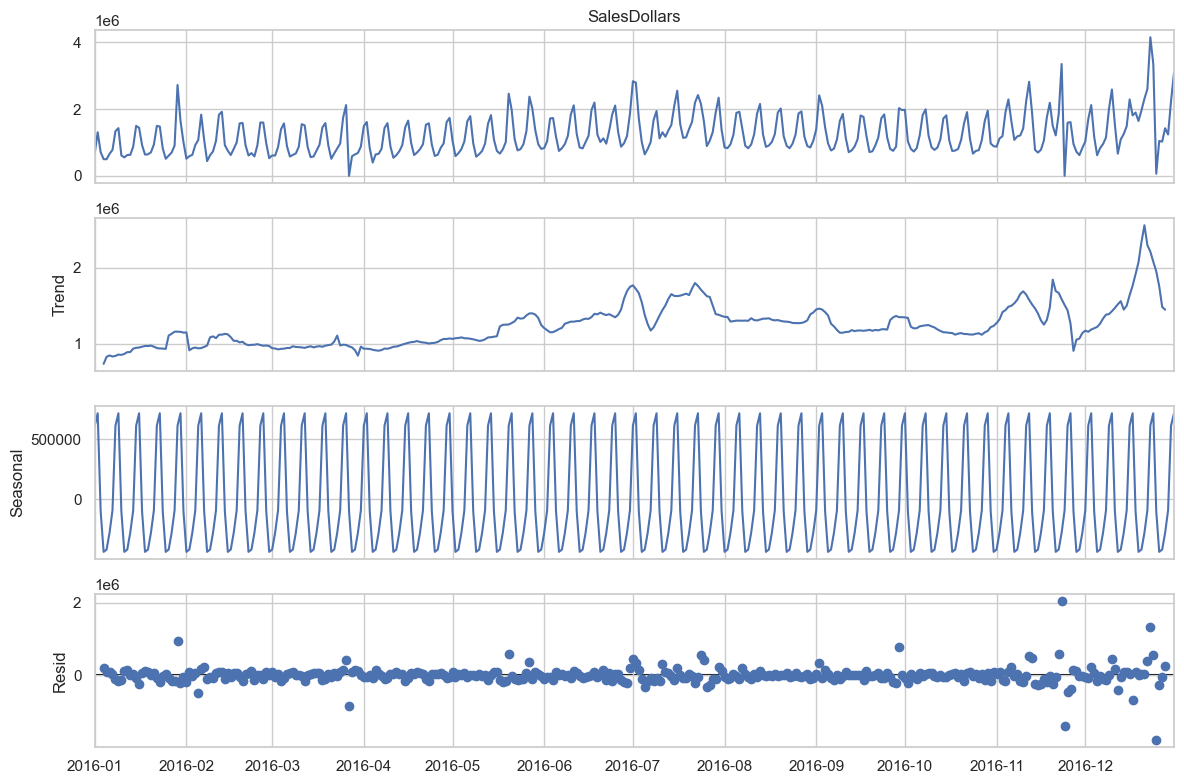

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# 1. Chuẩn bị dữ liệu: Group theo ngày -> Set tần suất là Ngày ('D') -> Điền 0 vào ngày không bán
ts_data = sales.groupby('SalesDate')['SalesDollars'].sum().asfreq('D').fillna(0)

# 2. Thực hiện Decomposition
# period=7: Tìm quy luật lặp lại mỗi 7 ngày (Thứ 2 - CN)
# model='additive': Dùng mô hình cộng (Doanh thu = Trend + Season + Resid)
result = seasonal_decompose(ts_data, model='additive', period=7)

# 3. Vẽ biểu đồ
plt.rcParams.update({'figure.figsize': (12, 8)})
result.plot()
plt.show()